In [1]:
full_path_where_plotstyle_directory_is_located = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/plottemplate-master/low_rad_plot_style'
import sys
sys.path.append(full_path_where_plotstyle_directory_is_located)

import LowRadPlotStyle as xps
xps.use('lowrad')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Spectra


### From Paper https://arxiv.org/pdf/0802.3566

In [3]:
data_black_curve = np.loadtxt('/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Dataset 0(2).csv', delimiter=',', skiprows=1)


In [4]:
year = 365 * 24 * 3600  # seconds in a year

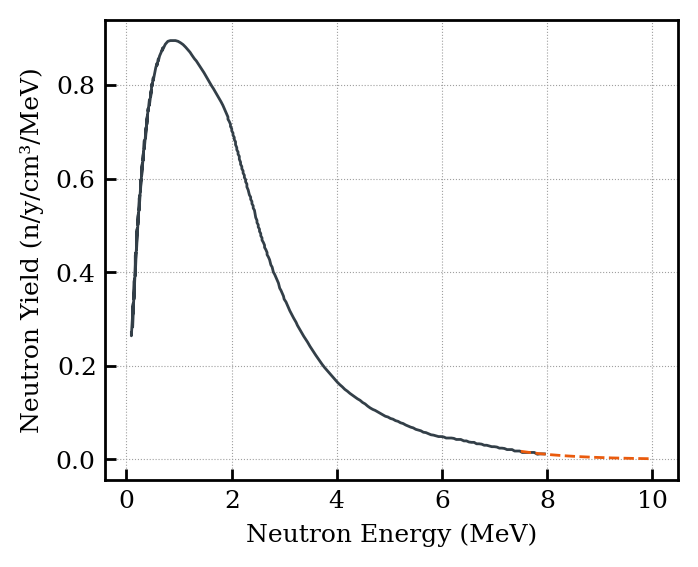

In [5]:
x = data_black_curve[:, 0]
y = data_black_curve[:, 1] * 1e-8 * year

mask = x > 7.6
x_tail = x[mask]
y_tail = y[mask]

def expo(x, A, k):
    return A * np.exp(-k * x)

popt, pcov = curve_fit(expo, x_tail, y_tail, p0=(y_tail.max(), 0.5))
A_fit, k_fit = popt

# 4. Extrapolation bis 10 MeV
x_ext = np.linspace(7.5, 10.0, 200)
y_ext = expo(x_ext, A_fit, k_fit)

# 5. Plot zum Vergleich
plt.plot(x, y,label='Combination of fission and (α,n) reactions',)
plt.plot(x_ext, y_ext, color=xps.colors['orange'], label='Extrapolated fit', linestyle='--', )
plt.xlabel('Neutron Energy (MeV)')
plt.ylabel('Neutron Yield (n/y/cm³/MeV)')
plt.grid(True)

plt.show()

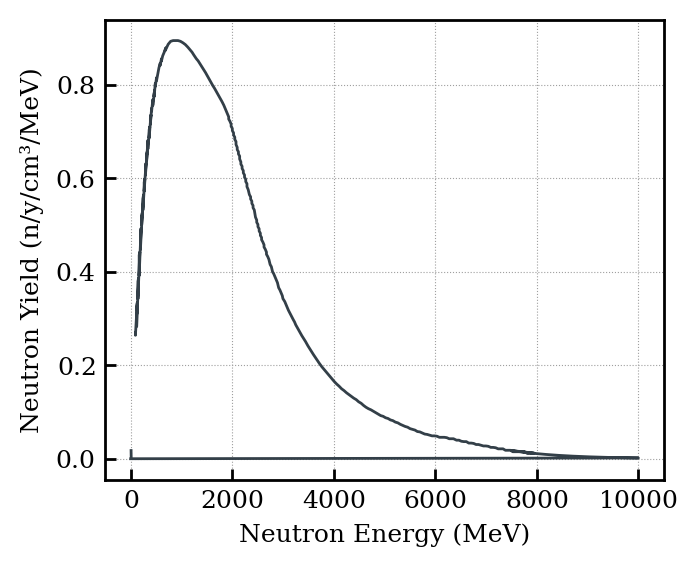

In [6]:
x_full = np.concatenate((x, x_ext))
y_full = np.concatenate((y, y_ext))

x_ex = [0]
y_ey = [0]

x_full = np.concatenate((x_full, x_ex))
y_full = np.concatenate((y_full, y_ey))



# 5. Plot zum Vergleich
plt.plot(x_full*1000, y_full,label='Combination of fission and (α,n) reactions',)
plt.plot(x_ext, y_ext, color=xps.colors['graphit'], label='Extrapolated fit')
plt.xlabel('Neutron Energy (MeV)')
plt.ylabel('Neutron Yield (n/y/cm³/MeV)')
plt.grid(True)


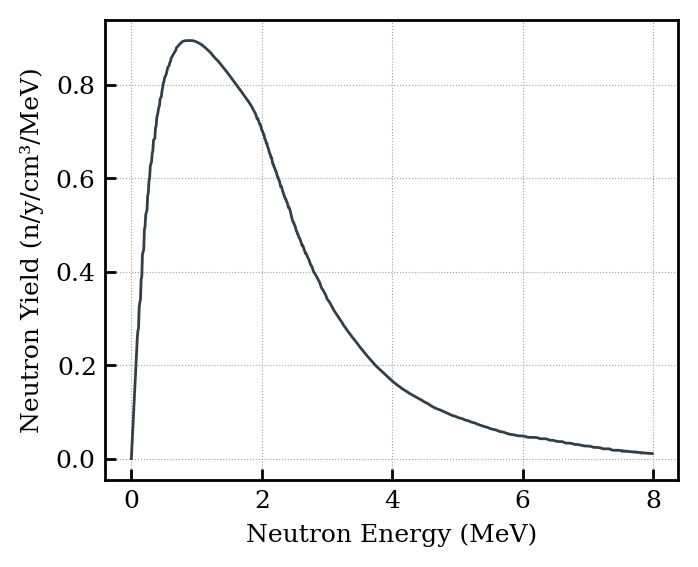

In [ ]:
from scipy.interpolate import interp1d

# Anzahl der gewünschten äquidistanten Bins
num_bins = 1001
x_eq = np.linspace(x_full.min(), x_full.max(), num_bins)

bin_breite = x_eq[1] - x_eq[0]
# Interpolation der y-Werte auf das neue Gitter
interp_func = interp1d(x_full, y_full, kind='linear', fill_value="extrapolate")
y_eq = interp_func(x_eq) #/ bin_breite

mask1 = 8 > x_eq
mask3 = 8 < x_ext
mask2 = (x_ext > 7.5) & (x_ext < 8)
x1 = x_eq[mask1]
y1 = y_eq[mask1]

x2 = x_ext[mask2]
y2 = y_ext[mask2]

x3 = x_ext[mask3]
y3 = y_ext[mask3]

plt.plot(x1, y1, label='Interpoliert (äquidistant)', color=xps.colors['graphit'])
#plt.plot(x2, y2, label='Interpoliert (äquidistant)', color=xps.colors['orange'], linestyle=':') # fits
#plt.plot(x3, y3, label='Interpoliert (äquidistant)', color=xps.colors['orange'])
#plt.xlim(-0.001,0.001)
#plt.ylim(-0.0001, 0.0001)

plt.xlabel('Neutron Energy (MeV)')
plt.ylabel('Neutron Yield (n/y/cm³/MeV)')
plt.grid(True)
plt.savefig('radio_spec_ohne.pdf', dpi=300)
plt.show()

In [8]:
s=sum(y_eq)
y_eq = y_eq / s  # Normalisierung
data = np.column_stack((x_eq, y_eq))

# data nach x sortieren
data = data[np.argsort(data[:, 0])]
np.savetxt('RadiogenicNeutronDistribution.txt', data, delimiter=' ', header="unit: MeV \nspectrum:", comments='')